# Latent SR mesh cascade experiment

Select one OBJ/GLB by index, adjust the experiment parameters, and run the existing support-only cascade evaluator. Intermediate files are created in a temporary directory and removed after the progression is displayed inline.

In [1]:
import os
import shlex
import subprocess
import sys
import tempfile
from pathlib import Path

from IPython.display import display
from PIL import Image

REPO = Path('/home/koussa/scratch/TRELLIS.2')
PYTHON = Path('/home/koussa/scratch/envs/trellis2/bin/python')
EVALUATOR = REPO / 'eval_obj_folder_latent_sr_stage_repeat_cascade.py'
COMPOSITOR = REPO / 'compose_stage_repeat_progression.py'
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))
import eval_obj_folder_latent_sr_stage_repeat_cascade as mesh_evaluator
MODEL_CACHE = {}  # Keeps one loaded model warm across experiment-cell reruns.

MODEL_PRESETS = {
    'noise025': {
        'run_dir': Path('/nfs/turbo/coe-jjparkcv-medium/gpranav/objxl_4k/outputs/triangle_field_latent_sr_flow_allres_avgfrom512_densitystats_rescond_noise025_shape_vae60k_56638595'),
        'apply_augmentation': True,
        'noise_level': 0.25,
    },
    'noaug': {
        'run_dir': Path('/nfs/turbo/coe-jjparkcv-medium/gpranav/objxl_4k/outputs/triangle_field_latent_sr_flow_allres_avgfrom512_densitystats_rescond_noaug_shape_vae60k_56638640'),
        'apply_augmentation': False,
        'noise_level': None,
    },
}


[SPARSE] Conv backend: flex_gemm; Attention backend: flash_attn


## Parameters
Change `OBJECT_INDEX` to select a mesh. The defaults reproduce the latest 50-step, one-repeat, fixed-resolution-condition experiment with all density statistics dropped.

In [23]:
# Model and object
MODEL_VARIANT = 'noise025'  # 'noise025' or 'noaug'
MESH_DIR = Path('/nfs/turbo/coe-jjparkcv-medium/gpranav/test_meshes')
OBJECT_INDEX = 1
RECURSIVE = False
CKPT = 'latest'  # Use 'latest' to resolve the newest available checkpoint.
EMA_RATE = '0.9999'  # Set to None for raw weights.

# Cascade and sampling
START_RESOLUTION = 64
STEPS = 11
STAGE_REPEATS = 12
EARLY_STAGE_REPEATS = None
EARLY_STAGE_REPEATS_THROUGH_RESOLUTION = None
SEED = 1
BATCH_SIZE = 1
NESTED_SUPPORTS = True
MAX_ACTIVE_VOXELS = 2_000_000
SUPPORT_CACHE_DIR = Path('/nfs/turbo/coe-jjparkcv-medium/gpranav/objxl_4k/outputs/triangle_field_latent_sr_flow_64to128_selfcond_input_allres_fullaux_noiseonly_density128_scratch_53303600/eval_test_meshes_all_stage_repeat12_cascade_128to512_supportonly_constantdensity128_m2p5_voxelscale_step0140000_ema09999_cfg1_basecfg0_steps11_noiseonly025_max2m/support_cache')

# Low-resolution field and shape CFG
BASE_GUIDANCE_STRENGTH = 0.0
GUIDANCE_STRENGTH = 1.0
SHAPE_GUIDANCE_STRENGTH = 6.0
DROP_SHAPE_CONDITIONING = False

# Per-voxel density condition
DROP_DENSITY_CONDITIONING = True
CONSTANT_DENSITY_CONDITIONING = False
CONSTANT_DENSITY_VALUE = -2.5
CONSTANT_DENSITY_BASE_RESOLUTION = 128
CONSTANT_DENSITY_SCALE_MODE = 'voxel_size'
DENSITY_GUIDANCE_STRENGTH = None
DENSITY_CONDITIONING_MAX_RESOLUTION = None

# Per-voxel elongation condition
DROP_ELONGATION_CONDITIONING = True
CONSTANT_ELONGATION_CONDITIONING = False
CONSTANT_ELONGATION_VALUE = 0.0
ELONGATION_GUIDANCE_STRENGTH = None
ELONGATION_CONDITIONING_MAX_RESOLUTION = None

# Scalar density statistics; None means that statistic is dropped.
DENSITY_STAT_MINIMUM = None
DENSITY_STAT_MEDIAN = None
DENSITY_STAT_MAXIMUM = -1
DENSITY_STAT_MINIMUM_GUIDANCE_STRENGTH = None
DENSITY_STAT_MAXIMUM_GUIDANCE_STRENGTH = 6
DENSITY_STATISTICS_BASE_RESOLUTION = 128
DENSITY_STATISTICS_SCALE_MODE = 'voxel_size'

# Resolution conditioning and model-matched low-resolution augmentation
FIXED_RESOLUTION_CONDITION = None  # Set to None to use each stage's resolution.
APPLY_CONDITIONING_AUGMENTATION = MODEL_PRESETS[MODEL_VARIANT]['apply_augmentation']
CONDITIONING_AUGMENTATION_NOISE_LEVEL = MODEL_PRESETS[MODEL_VARIANT]['noise_level']
CONDITIONING_AUGMENTATION_BLUR_SIGMA = None
CONDITIONING_AUGMENTATION_DISABLE_BLUR = True

# Inline progression display
PROGRESSION_CHANNEL = 'd_tri'  # 'd_tri' or 'd_vert'
PANEL_SIZE = 384
PROGRESSION_ONLY = True  # Skip support/condition/pred-z0 and d_vert renders.
EXTRA_EVAL_ARGS = []


## Available objects

In [24]:
iterator = MESH_DIR.rglob('*') if RECURSIVE else MESH_DIR.iterdir()
mesh_paths = sorted(
    path.resolve()
    for path in iterator
    if path.is_file() and path.suffix.lower() in {'.obj', '.glb'}
)
if not mesh_paths:
    raise FileNotFoundError(f'No OBJ/GLB meshes found under {MESH_DIR}')
if not 0 <= OBJECT_INDEX < len(mesh_paths):
    raise IndexError(f'OBJECT_INDEX must be in [0, {len(mesh_paths) - 1}]')
for index, path in enumerate(mesh_paths):
    marker = '  < selected' if index == OBJECT_INDEX else ''
    print(f'{index:3d}: {path.name}{marker}')


  0: 02_robot_dog_input.glb
  1: 05_goblin_input.glb  < selected
  2: 06_house_input.glb
  3: 10_walle_robot_input.glb
  4: 11_cargo_van_input.glb
  5: 12_vc_biplane_input.glb
  6: 13_vc_chess_input.glb
  7: 14_vc_chest_input.glb
  8: 15_vc_lantern_input.glb
  9: 21_lod_deer_input.glb
 10: 22_lod_generator_input.glb


## Run and show progression
This cell evaluates only the selected mesh. The first run loads the model; later reruns reuse it unless the model/checkpoint/EMA/start stage changes. It embeds the progression image and removes temporary stage renders afterward.

Running object 1: 05_goblin_input.glb
/home/koussa/scratch/envs/trellis2/bin/python /home/koussa/scratch/TRELLIS.2/eval_obj_folder_latent_sr_stage_repeat_cascade.py --mesh_dir /nfs/turbo/coe-jjparkcv-medium/gpranav/test_meshes --mesh_index 1 --run_dir /nfs/turbo/coe-jjparkcv-medium/gpranav/objxl_4k/outputs/triangle_field_latent_sr_flow_allres_avgfrom512_densitystats_rescond_noise025_shape_vae60k_56638595 --ckpt latest --batch_size 1 --steps 11 --stage_repeats 12 --start_resolution 64 --seed 1 --base_guidance_strength 0.0 --guidance_strength 1.0 --max_active_voxels 2000000 --support_cache_dir /nfs/turbo/coe-jjparkcv-medium/gpranav/objxl_4k/outputs/triangle_field_latent_sr_flow_64to128_selfcond_input_allres_fullaux_noiseonly_density128_scratch_53303600/eval_test_meshes_all_stage_repeat12_cascade_128to512_supportonly_constantdensity128_m2p5_voxelscale_step0140000_ema09999_cfg1_basecfg0_steps11_noiseonly025_max2m/support_cache --constant_density_value -2.5 --constant_density_base_resolutio

Sampling latent SR:  91%|█████████ | 10/11 [00:03<00:00,  3.04it/s]

Sampling latent SR: 100%|██████████| 11/11 [00:03<00:00,  3.02it/s]


Saved mesh-folder support-only cascade eval to /tmp/trellis_latent_sr_notebook_kuphg4rt/eval
Saved 1 progression sheets to /tmp/trellis_latent_sr_notebook_kuphg4rt/eval/progression_d_tri_first_view


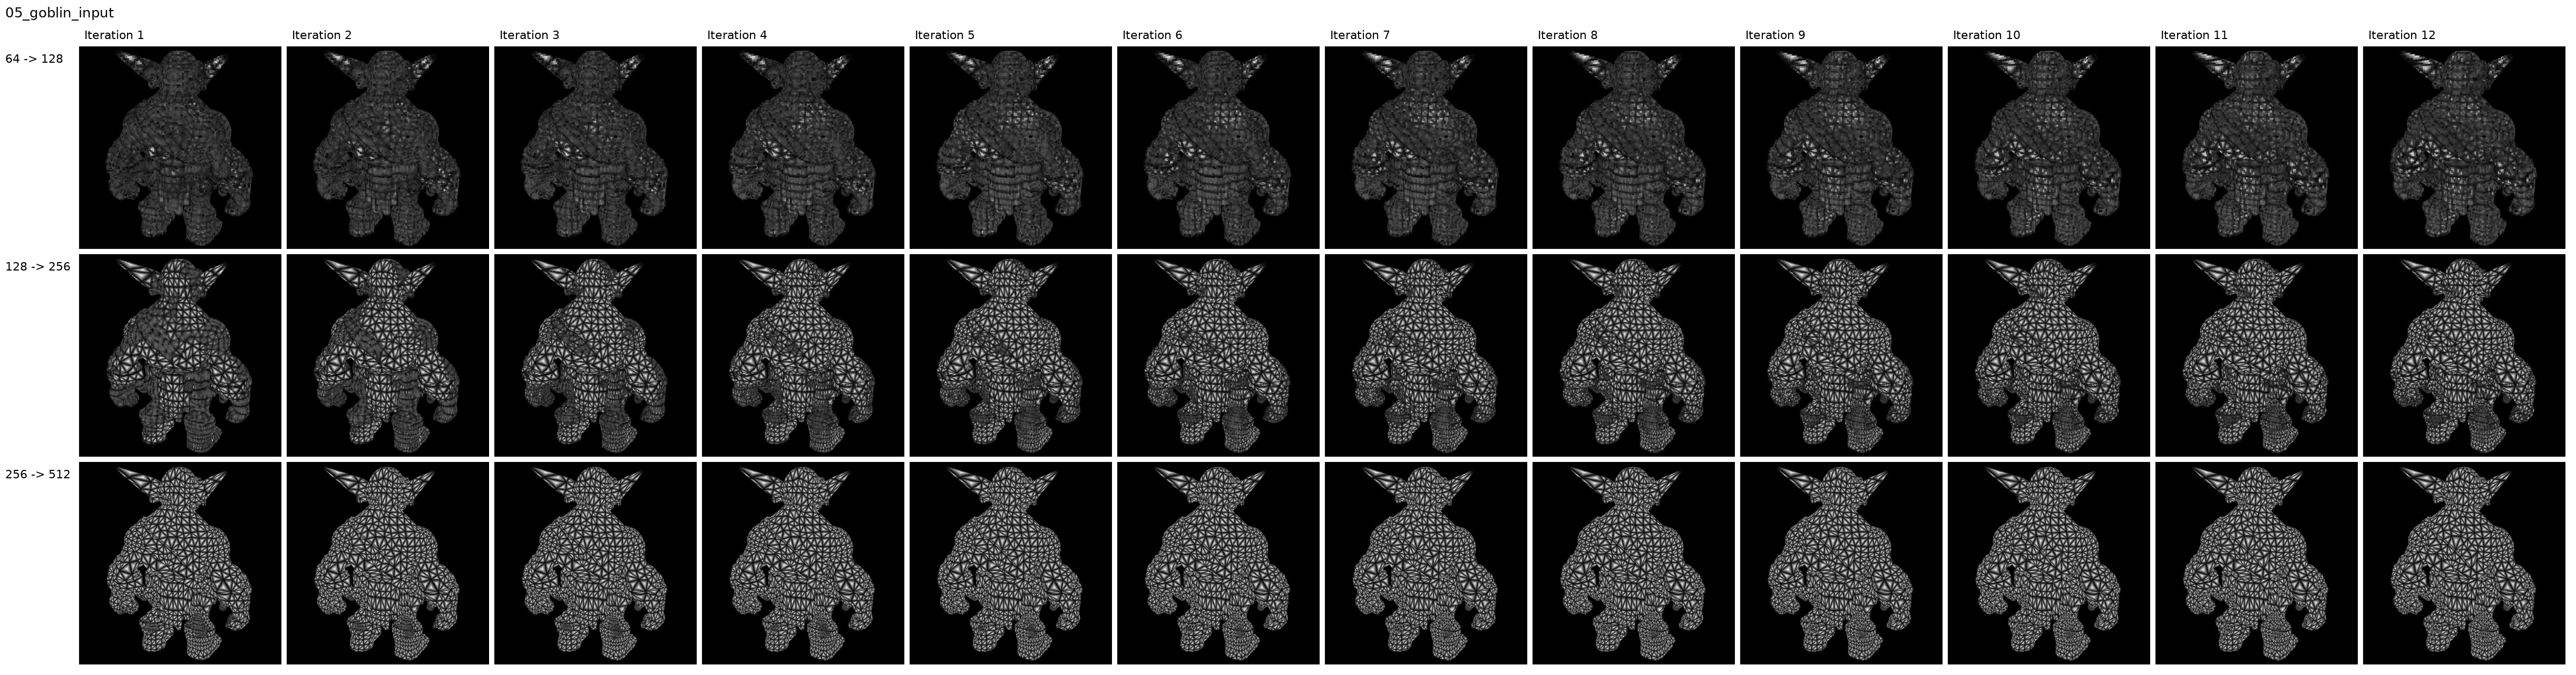

In [25]:
def add_value(command, option, value):
    if value is not None:
        command.extend([option, str(value)])

preset = MODEL_PRESETS[MODEL_VARIANT]
command = [
    str(PYTHON), str(EVALUATOR),
    '--mesh_dir', str(MESH_DIR),
    '--mesh_index', str(OBJECT_INDEX),
    '--run_dir', str(preset['run_dir']),
    '--ckpt', str(CKPT),
    '--batch_size', str(BATCH_SIZE),
    '--steps', str(STEPS),
    '--stage_repeats', str(STAGE_REPEATS),
    '--start_resolution', str(START_RESOLUTION),
    '--seed', str(SEED),
    '--base_guidance_strength', str(BASE_GUIDANCE_STRENGTH),
    '--guidance_strength', str(GUIDANCE_STRENGTH),
    '--max_active_voxels', str(MAX_ACTIVE_VOXELS),
    '--support_cache_dir', str(SUPPORT_CACHE_DIR),
    '--constant_density_value', str(CONSTANT_DENSITY_VALUE),
    '--constant_density_base_resolution', str(CONSTANT_DENSITY_BASE_RESOLUTION),
    '--constant_density_scale_mode', CONSTANT_DENSITY_SCALE_MODE,
    '--constant_elongation_value', str(CONSTANT_ELONGATION_VALUE),
    '--density_statistics_base_resolution', str(DENSITY_STATISTICS_BASE_RESOLUTION),
    '--density_statistics_scale_mode', DENSITY_STATISTICS_SCALE_MODE,
]
add_value(command, '--ema_rate', EMA_RATE)
add_value(command, '--early_stage_repeats', EARLY_STAGE_REPEATS)
add_value(command, '--early_stage_repeats_through_resolution', EARLY_STAGE_REPEATS_THROUGH_RESOLUTION)
add_value(command, '--shape_guidance_strength', SHAPE_GUIDANCE_STRENGTH)
add_value(command, '--density_guidance_strength', DENSITY_GUIDANCE_STRENGTH)
add_value(command, '--density_conditioning_max_resolution', DENSITY_CONDITIONING_MAX_RESOLUTION)
add_value(command, '--elongation_guidance_strength', ELONGATION_GUIDANCE_STRENGTH)
add_value(command, '--elongation_conditioning_max_resolution', ELONGATION_CONDITIONING_MAX_RESOLUTION)
add_value(command, '--density_stat_minimum', DENSITY_STAT_MINIMUM)
add_value(command, '--density_stat_median', DENSITY_STAT_MEDIAN)
add_value(command, '--density_stat_maximum', DENSITY_STAT_MAXIMUM)
add_value(command, '--density_stat_minimum_guidance_strength', DENSITY_STAT_MINIMUM_GUIDANCE_STRENGTH)
add_value(command, '--density_stat_maximum_guidance_strength', DENSITY_STAT_MAXIMUM_GUIDANCE_STRENGTH)
add_value(command, '--fixed_resolution_condition', FIXED_RESOLUTION_CONDITION)
if RECURSIVE: command.append('--recursive')
if PROGRESSION_ONLY: command.append('--progression_only')
if NESTED_SUPPORTS: command.append('--nested_supports')
if DROP_SHAPE_CONDITIONING: command.append('--drop_shape_conditioning')
if DROP_DENSITY_CONDITIONING: command.append('--drop_density_conditioning')
if CONSTANT_DENSITY_CONDITIONING: command.append('--constant_density_conditioning')
if DROP_ELONGATION_CONDITIONING: command.append('--drop_elongation_conditioning')
if CONSTANT_ELONGATION_CONDITIONING: command.append('--constant_elongation_conditioning')
if APPLY_CONDITIONING_AUGMENTATION:
    command.append('--apply_conditioning_augmentation')
    add_value(command, '--conditioning_augmentation_noise_level', CONDITIONING_AUGMENTATION_NOISE_LEVEL)
    add_value(command, '--conditioning_augmentation_blur_sigma', CONDITIONING_AUGMENTATION_BLUR_SIGMA)
    if CONDITIONING_AUGMENTATION_DISABLE_BLUR:
        command.append('--conditioning_augmentation_disable_blur')
command.extend(map(str, EXTRA_EVAL_ARGS))

env = os.environ.copy()
env['FLEX_GEMM_USE_AUTOTUNE_CACHE'] = '1'
env['FLEX_GEMM_AUTOSAVE_AUTOTUNE_CACHE'] = '1'
print(f'Running object {OBJECT_INDEX}: {mesh_paths[OBJECT_INDEX].name}')
print(shlex.join(command))

with tempfile.TemporaryDirectory(prefix='trellis_latent_sr_notebook_') as temporary_dir:
    eval_dir = Path(temporary_dir) / 'eval'
    command.extend(['--output_dir', str(eval_dir)])
    eval_args = mesh_evaluator.parse_args(command[2:])
    mesh_evaluator.main(eval_args, model_cache=MODEL_CACHE)
    subprocess.run([
        str(PYTHON), str(COMPOSITOR),
        '--eval_dir', str(eval_dir),
        '--channel', PROGRESSION_CHANNEL,
        '--panel_size', str(PANEL_SIZE),
    ], cwd=REPO, env=env, check=True)
    progression_paths = sorted((eval_dir / f'progression_{PROGRESSION_CHANNEL}_first_view').glob('*.jpg'))
    if len(progression_paths) != 1:
        raise RuntimeError(f'Expected one progression image, found {len(progression_paths)}')
    progression = Image.open(progression_paths[0]).copy()
    display(progression)
